## Imports and Functions

In [1]:
import numpy as np
from pynwb import read_nwb
from matplotlib import pyplot as plt

from CSE583_humanSayMonkeyDo.core import (
    say_hello,
    get_nwbs,
    get_windowed_pos_chunk,
    get_chunk_spikes_binned_windowed,
    plot_firing_rate_heatmap,
    get_movement_onset_times,
    train_lda_classifier,
    plot_lda_results,
)


In [2]:

say_hello('hello')


'Hello, hello!'

## Using Data

In [3]:
#Get paths to monkey NWB files
monkey_paths = get_nwbs('monkey', 2)
#Load first NWB file
m_nwbfile = read_nwb(monkey_paths[0])
#Visualize entries
m_nwbfile

Data type,object
Shape,"(4,)"
Array size,32.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),32
Compressed size (bytes),64
Compression ratio,0.5
Data type,float64
Shape,"(100516, 2)"


In [4]:

#Get paths to human NWB files
human_paths = get_nwbs('human', 2)

#Load first NWB file
h_nwbfile = read_nwb(human_paths[0])
#Visualize entries
h_nwbfile

root pynwb.file.NWBFile at 0x6051729872
Fields:
  acquisition: {
    ElectricalSeries <class 'pynwb.ecephys.ElectricalSeries'>
  }
  devices: {
    auto_device <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    auto_group <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  epochs: epochs <class 'pynwb.epoch.TimeIntervals'>
  file_create_date: [datetime.datetime(2019, 6, 19, 13, 7, 30, 430300, tzinfo=tzoffset(None, -25200))]
  identifier: GP33_B30
  institution: University of California, San Francisco
  intervals: {
    epochs <class 'pynwb.epoch.TimeIntervals'>,
    invalid_times <class 'pynwb.epoch.TimeIntervals'>,
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  invalid_times: invalid_times <class 'pynwb.epoch.TimeIntervals'>
  lab: Chang Lab
  session_description: GP33_B30
  session_id: GP33_B30
  session_start_time: 1900-01-01 08:00:00+00:00
  subject: subject pynwb.file.Subject at 0x6051727312
Fields:
  species: Homo sapiens
  subject_id: GP33

  timestamps_reference_time: 1900-01-01 08:00:00+00:00
  trials: trials <class 'pynwb.epoch.TimeIntervals'>

In [5]:
#def get_kinematics(nwbfile):
#    if nwbfile.
def timestamps_to_binary(timestamps, start_stop_times):
    """
    Convert timestamps to binary time series based on start/stop intervals.
    
    Parameters
    ----------
    timestamps : array-like
        Array of timestamps to evaluate.
    start_stop_times : array-like
        2D array of shape (n, 2) where each row contains [start_time, stop_time].
        The first column contains start times, the second column contains stop times.
    
    Returns
    -------
    numpy.ndarray
        Binary array of shape (len(timestamps),) where 1 indicates the timestamp
        falls within at least one start/stop interval, and 0 indicates it falls
        outside all intervals.
    
    Raises
    ------
    ValueError
        If start_stop_times is not a 2D array with 2 columns.
        If any stop time is less than its corresponding start time.
    
    Examples
    --------
    >>> timestamps = np.array([0, 1, 2, 3, 4, 5])
    >>> start_stop = np.array([[1, 3], [4, 5]])
    >>> timestamps_to_binary(timestamps, start_stop)
    array([0, 1, 1, 1, 1, 1])
    
    >>> timestamps = np.array([0.5, 1.5, 2.5, 3.5])
    >>> start_stop = np.array([[1.0, 2.0]])
    >>> timestamps_to_binary(timestamps, start_stop)
    array([0, 1, 0, 0])
    
    Notes
    -----
    If intervals overlap, timestamps within overlapping regions are still marked
    as 1 (within interval). The function uses vectorized operations for efficiency.
    Interval boundaries are inclusive: timestamps equal to start or stop times
    are considered within the interval.
    """
    import numpy as np
    
    timestamps = np.asarray(timestamps)
    start_stop_times = np.asarray(start_stop_times)
    
    # Validate input shape
    if start_stop_times.ndim != 2 or start_stop_times.shape[1] != 2:
        raise ValueError(
            "start_stop_times must be a 2D array with 2 columns "
            f"(start, stop), got shape {start_stop_times.shape}"
        )
    
    # Validate start <= stop for all pairs
    if np.any(start_stop_times[:, 1] < start_stop_times[:, 0]):
        raise ValueError("All stop times must be >= their corresponding start times")
    
    # Initialize binary array
    binary_series = np.zeros(len(timestamps), dtype=int)
    
    # Check each interval
    for start, stop in start_stop_times:
        # Mark timestamps within this interval as 1
        within_interval = (timestamps >= start) & (timestamps <= stop)
        binary_series = np.logical_or(binary_series, within_interval).astype(int)
    
    return binary_series

def samples_to_timeseries(n_samples, fs):
    """
    Convert number of samples and sampling frequency to a time series.
    
    Parameters
    ----------
    n_samples : int
        Number of samples in the time series.
    fs : float
        Sampling frequency in Hz.
    
    Returns
    -------
    numpy.ndarray
        Array of time values starting at 0, with shape (n_samples,).
    
    Raises
    ------
    ValueError
        If n_samples is not positive or fs is not positive.
    
    Examples
    --------
    >>> samples_to_timeseries(5, 100)
    array([0.  , 0.01, 0.02, 0.03, 0.04])
    
    >>> samples_to_timeseries(10, 1000)
    array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009])
    
    Notes
    -----
    The time series is generated using numpy.arange with a step size of 1/fs.
    The resulting array will have exactly n_samples elements.
    """
    import numpy as np
    
    if n_samples <= 0:
        raise ValueError("n_samples must be positive")
    if fs <= 0:
        raise ValueError("fs must be positive")
    
    return np.arange(n_samples) / fs

def get_monkey_kinematics(nwbfile, kin_type='Position'):
    """
    Extract cursor position kinematics from monkey NWB file.
    
    This function retrieves the x/y cursor position data from a monkey
    performing a cursor control task. The cursor position represents the
    location on screen controlled by the animal's arm movements over time.
    
    Parameters
    ----------
    nwbfile : pynwb.NWBFile
        NWB file object containing behavioral data from monkey experiments.
        Must contain:
        - processing['behavior'].data_interfaces['Position']: Position data
        - spatial_series['cursor_pos']: Cursor position time series with
          .data and .timestamps attributes
    
    Returns
    -------
    kinematic : numpy.ndarray
        Array of shape (n_samples, 2) containing x/y cursor positions on screen.
        Each row represents [x_position, y_position] at a given time point.
    timestamps : numpy.ndarray
        Array of shape (n_samples,) containing the timestamp for each cursor
        position sample.
    kin_type: String- "Position" or "Velocity"
        Specifying to return either position or velocity kinematic information
    
    Raises
    ------
    KeyError
        If 'behavior' processing module, 'Position' interface, or 'cursor_pos'
        spatial series is not found in the NWB file.
    AttributeError
        If required .data or .timestamps attributes are missing.
    
    Examples
    --------
    >>> kinematic, timestamps = get_monkey_kinematics(nwbfile)
    >>> print(f"Cursor data shape: {kinematic.shape}")
    >>> print(f"Recording duration: {timestamps[-1] - timestamps[0]:.2f} seconds")
    >>> print(f"X range: [{kinematic[:, 0].min()}, {kinematic[:, 0].max()}]")
    
    Notes
    -----
    The cursor position data represents screen coordinates controlled by the
    monkey's arm movements during behavioral tasks. Timestamps are stored
    separately and may not be uniformly sampled.
    """
    assert kin_type in ("Position", "Velocity"), f"kin_type must be 'Position' or 'Velocity', got {kin_type}"
    if kin_type=="Position":
        kinematic = nwbfile.processing['behavior'].data_interfaces[kin_type].spatial_series['cursor_pos']
    elif kin_type=="Velocity":
        kinematic = nwbfile.processing['behavior'].data_interfaces[kin_type].time_series['cursor_vel']

    timestamps = kinematic.timestamps[:]
    kinematic = kinematic.data[:]
    
    
    return kinematic, timestamps



def get_kinematics(nwbfile, kin_type="Position"):
    """
    Extract kinematic data from NWB file based on subject species.
    
    This function routes to species-specific kinematic extraction methods
    and returns kinematic data along with metadata describing the data type
    and subject species.
    
    Parameters
    ----------
    nwbfile : pynwb.NWBFile
        NWB file object containing subject information and kinematic data.
        Must have nwbfile.subject.species set to either 'Macaca mulatta'
        or 'Homo sapiens'.
    kin_type: String
        Only relevant for monkey kinematics, specifies either velocity 
        or position kinematics
    Returns
    -------
    kinematic : numpy.ndarray
        Kinematic data array. Shape and content depend on species:
        - Macaca mulatta: (n_samples, 2) array of x/y cursor positions
        - Homo sapiens: (n_samples,) binary array of speaking activity
    timestamps : numpy.ndarray
        Array of shape (n_samples,) containing timestamps for each sample.
    metadata : dict
        Dictionary containing kinematic metadata with keys:
        - 'species': Subject species name
        - 'kinematic_type': Type of kinematic data ('cursor_position' or 'speech_binary')
    
    Raises
    ------
    ValueError
        If subject species is neither 'Macaca mulatta' nor 'Homo sapiens'.
    AttributeError
        If nwbfile.subject.species is not accessible.
    
    Examples
    --------
    >>> kinematic, timestamps, metadata = get_kinematics(nwbfile)
    >>> print(f"Species: {metadata['species']}")
    >>> print(f"Kinematic type: {metadata['kinematic_type']}")
    >>> print(f"Data shape: {kinematic.shape}")
    
    Notes
    -----
    This function serves as a unified interface for extracting kinematic data
    from both monkey cursor control experiments and human speech experiments.
    The metadata dictionary allows downstream code to properly interpret the
    kinematic data based on its type and source species.
    """
    if nwbfile.subject.species == 'Macaca mulatta':
        kinematic, timestamps = get_monkey_kinematics(nwbfile, kin_type)
        metadata = {
            'species': 'Macaca mulatta',
            'kinematic_type': 'cursor_position'
        }
    elif nwbfile.subject.species == 'Homo sapiens':
        kinematic, timestamps = get_human_kinematics(nwbfile)
        metadata = {
            'species': 'Homo sapiens',
            'kinematic_type': 'speech_binary'
        }
    else:
        raise ValueError("Missing required field: NWB file does not have monkey or human species")
    
    return kinematic, timestamps, metadata

In [6]:
def get_monkey_trial_times(nwbfile):
    """
    Extract trial timing information from monkey NWB file.
    
    This function retrieves the start time, go cue time, and stop time for
    each trial in a monkey cursor control experiment. Trials with missing
    (NaN) go cue times are excluded.
    
    Parameters
    ----------
    nwbfile : pynwb.NWBFile
        NWB file object containing monkey trial data.
        Must have nwbfile.trials with 'start_time', 'go_cue_time', and
        'stop_time' columns.
    
    Returns
    -------
    trial_times : pandas.DataFrame
        DataFrame of shape (n_valid_trials, 3) with columns:
        - 'start_time': Trial start time in seconds
        - 'go_cue_time': Time when movement cue was presented in seconds
        - 'stop_time': Trial end time in seconds
        Only includes trials where go_cue_time is not NaN.
    
    Raises
    ------
    KeyError
        If required columns ('start_time', 'go_cue_time', 'stop_time') are
        not found in nwbfile.trials.
    AttributeError
        If nwbfile.trials is not accessible.
    
    Examples
    --------
    >>> trial_times = get_monkey_trial_times(nwbfile)
    >>> print(f"Number of valid trials: {len(trial_times)}")
    >>> print(f"Average trial duration: {(trial_times['stop_time'] - trial_times['start_time']).mean():.2f}s")
    
    Notes
    -----
    The go_cue_time marks when the animal receives the signal to begin
    movement towards the target. This typically occurs after the start_time
    and before the stop_time. Trials without a valid go_cue_time (NaN values)
    are filtered out and not included in the returned DataFrame.
    """
    trial_times = nwbfile.trials[:][['start_time', 'go_cue_time', 'stop_time']]
    valid_go_cue = ~np.isnan(trial_times['go_cue_time'])
    trial_times = trial_times[valid_go_cue]
    return trial_times


def get_human_trial_times(nwbfile):
    """
    Extract trial timing information from human speech NWB file.
    
    This function retrieves timing information for speaking trials only,
    filtering out non-speaking trials. Returns the start time, consonant-vowel
    transition time, and stop time for each speaking trial.
    
    Parameters
    ----------
    nwbfile : pynwb.NWBFile
        NWB file object containing human speech trial data.
        Must have nwbfile.trials with 'speak', 'start_time',
        'cv_transition_time', and 'stop_time' columns.
    
    Returns
    -------
    trial_times : pandas.DataFrame
        DataFrame of shape (n_speaking_trials, 3) with columns:
        - 'start_time': Trial start time in seconds
        - 'cv_transition_time': Consonant-vowel transition time in seconds
        - 'stop_time': Trial end time in seconds
        Only includes trials where speak==True.
    
    Raises
    ------
    KeyError
        If required columns ('speak', 'start_time', 'cv_transition_time',
        'stop_time') are not found in nwbfile.trials.
    AttributeError
        If nwbfile.trials is not accessible.
    
    Examples
    --------
    >>> trial_times = get_human_trial_times(nwbfile)
    >>> print(f"Number of speaking trials: {len(trial_times)}")
    >>> cv_delays = trial_times['cv_transition_time'] - trial_times['start_time']
    >>> print(f"Average time to CV transition: {cv_delays.mean():.3f}s")
    
    Notes
    -----
    This function filters trials to include only those where the subject was
    speaking (speak==True). The cv_transition_time marks the point during
    speech production when articulation transitions from consonant to vowel,
    which is an important landmark in speech motor control analysis.
    """
    data = nwbfile.trials[:]
    remove_non_speaking = data['speak'] == True
    data = data[remove_non_speaking]
    trial_times = data[["start_time", "cv_transition_time", "stop_time"]]
    return trial_times

def get_trial_times(nwbfile):
    """
    Extract trial timing information from NWB file based on subject species.
    
    This function routes to species-specific trial time extraction methods
    and returns trial timing data along with metadata describing the trial
    type and subject species.
    
    Parameters
    ----------
    nwbfile : pynwb.NWBFile
        NWB file object containing subject information and trial data.
        Must have nwbfile.subject.species set to either 'Macaca mulatta'
        or 'Homo sapiens'.
    
    Returns
    -------
    trial_times : pandas.DataFrame
        DataFrame of shape (n_trials, 3) containing trial timing information.
        Columns depend on species:
        - Macaca mulatta: ['start_time', 'go_cue_time', 'stop_time']
        - Homo sapiens: ['start_time', 'cv_transition_time', 'stop_time']
    metadata : dict
        Dictionary containing trial metadata with keys:
        - 'species': Subject species name
        - 'trial_type': Type of trial ('reach' for monkey, 'speech' for human)
    
    Raises
    ------
    ValueError
        If subject species is neither 'Macaca mulatta' nor 'Homo sapiens'.
    AttributeError
        If nwbfile.subject.species is not accessible.
    
    Examples
    --------
    >>> trial_times, metadata = get_trial_times(nwbfile)
    >>> print(f"Species: {metadata['species']}")
    >>> print(f"Trial type: {metadata['trial_type']}")
    >>> print(f"Number of trials: {len(trial_times)}")
    >>> print(f"Columns: {trial_times.columns.tolist()}")
    
    Notes
    -----
    This function serves as a unified interface for extracting trial timing
    data from both monkey reach experiments and human speech experiments.
    The metadata dictionary allows downstream code to properly interpret the
    trial timing columns based on the trial type and source species.
    """
    if nwbfile.subject.species == 'Macaca mulatta':
        trial_times = get_monkey_trial_times(nwbfile)
        metadata = {
            'species': 'Macaca mulatta',
            'trial_type': 'reach'
        }
    elif nwbfile.subject.species == 'Homo sapiens':
        trial_times = get_human_trial_times(nwbfile)
        metadata = {
            'species': 'Homo sapiens',
            'trial_type': 'speech'
        }
    else:
        raise ValueError("Missing required field: NWB file does not have monkey or human species")
    
    trial_times.columns = ['trial_start', 'go', 'trial_end']
    return trial_times, metadata
# Lets view the data stored in the NWB file


In [7]:
def map_vowels_to_unit_circle():
    """
    Map vowel sounds to positions on a unit circle based on phonetic features.
    
    The mapping uses the traditional vowel space where:
    - Front vowels (ee) are on the right
    - Back vowels (aa, oo) are on the left
    - High vowels (ee, oo) are at the top
    - Low vowels (aa) are at the bottom
    
    Returns
    -------
    vowel_positions : dict
        Dictionary mapping vowel categories to (x, y) coordinates on unit circle.
    vowel_angles : dict
        Dictionary mapping vowel categories to angles in radians.
    
    Examples
    --------
    >>> positions = map_vowels_to_unit_circle()
    >>> print(positions['vowel_positions']['front_high'])
    (1.0, 0.0)
    """
    vowel_angles = {
        'front_high': 0,           # /i/ "ee" - 0° (right, like 3 o'clock)
        'back_high': 2 * np.pi / 3,  # /u/ "oo" - 120° (upper left)
        'back_low': 4 * np.pi / 3    # /ɑ/ "aa" - 240° (lower left)
    }
    
    vowel_positions = {}
    for vowel, angle in vowel_angles.items():
        x = np.cos(angle)
        y = np.sin(angle)
        vowel_positions[vowel] = (x, y)
    
    return {
        'vowel_positions': vowel_positions,
        'vowel_angles': vowel_angles
    }


def encode_sounds_to_2d(sound_list):
    """
    Encode a list of sounds into 2D coordinates on the unit circle.
    
    Parameters
    ----------
    sound_list : list of str
        List of sound strings (e.g., ['baa', 'dee', 'foo']).
        Each sound should end with 'aa', 'ee', or 'oo'.
    
    Returns
    -------
    coordinates : numpy.ndarray
        Array of shape (n_sounds, 2) containing (x, y) coordinates
        for each sound on the unit circle.
    vowel_types : list of str
        List of vowel categories corresponding to each sound.
    
    Examples
    --------
    >>> sounds = ['baa', 'dee', 'foo']
    >>> coords, vowels = encode_sounds_to_2d(sounds)
    >>> print(coords)
    [[-0.5  -0.866]
     [ 1.    0.   ]
     [-0.5   0.866]]
    """
    # Get vowel mappings
    mapping = map_vowels_to_unit_circle()
    positions = mapping['vowel_positions']
    
    # Create lookup from vowel suffix to category
    vowel_suffix_to_category = {
        'aa': 'back_low',
        'ee': 'front_high',
        'oo': 'back_high'
    }
    
    # Encode each sound
    coordinates = []
    vowel_types = []
    
    for sound in sound_list:
        # Extract vowel suffix (last 2 characters)
        vowel_suffix = sound[-2:]
        
        # Get vowel category
        vowel_category = vowel_suffix_to_category.get(vowel_suffix)
        
        if vowel_category is None:
            raise ValueError(f"Unknown vowel suffix '{vowel_suffix}' in sound '{sound}'")
        
        # Get coordinates
        x, y = positions[vowel_category]
        coordinates.append([x, y])
        vowel_types.append(vowel_category)
    
    return np.array(coordinates), vowel_types


def generate_phonetic_kinematics(timestamps, start_stop_times, coordinates):
    """
    Generate interpolated phonetic kinematic trajectories for vowel transitions.
    
    This function creates a 2D kinematic time series that interpolates from
    (0, 0) to target vowel coordinates during each vowel transition period.
    Outside of transition periods, the kinematic values are (0, 0).
    
    Parameters
    ----------
    timestamps : array-like
        1D array of timestamps for the kinematic time series.
    start_stop_times : array-like
        2D array of shape (n_transitions, 2) where each row contains
        [start_time, stop_time] for a vowel transition period.
    coordinates : array-like
        2D array of shape (n_transitions, 2) containing the target (x, y)
        coordinates for each vowel transition. Each row corresponds to the
        matching row in start_stop_times.
    
    Returns
    -------
    phonetic_kinematics : numpy.ndarray
        2D array of shape (len(timestamps), 2) containing interpolated
        (x, y) kinematic values. During each transition period, values
        interpolate linearly from (0, 0) to the target coordinates.
        Outside transition periods, values are (0, 0).
    
    Raises
    ------
    ValueError
        If start_stop_times and coordinates have different numbers of rows.
        If start_stop_times is not shape (n, 2).
        If coordinates is not shape (n, 2).
    
    Examples
    --------
    >>> timestamps = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5])
    >>> start_stop_times = np.array([[0.1, 0.3]])
    >>> coordinates = np.array([[1.0, 0.5]])
    >>> kinematics = generate_phonetic_kinematics(timestamps, start_stop_times, coordinates)
    >>> print(kinematics)
    [[0.   0.  ]
     [0.   0.  ]
     [0.5  0.25]
     [1.   0.5 ]
     [0.   0.  ]
     [0.   0.  ]]
    
    Notes
    -----
    The function performs linear interpolation from (0, 0) at the start_time
    to the target coordinates at the stop_time for each transition period.
    If transition periods overlap, the last transition takes precedence.
    """
    import numpy as np
    
    # Convert inputs to numpy arrays
    timestamps = np.asarray(timestamps)
    start_stop_times = np.asarray(start_stop_times)
    coordinates = np.asarray(coordinates)
    
    # Validate inputs
    if start_stop_times.ndim != 2 or start_stop_times.shape[1] != 2:
        raise ValueError(
            f"start_stop_times must be shape (n, 2), got {start_stop_times.shape}"
        )
    
    if coordinates.ndim != 2 or coordinates.shape[1] != 2:
        raise ValueError(
            f"coordinates must be shape (n, 2), got {coordinates.shape}"
        )
    
    if start_stop_times.shape[0] != coordinates.shape[0]:
        raise ValueError(
            f"start_stop_times and coordinates must have same number of rows, "
            f"got {start_stop_times.shape[0]} and {coordinates.shape[0]}"
        )
    
    # Initialize output array with zeros
    phonetic_kinematics = np.zeros((len(timestamps), 2))
    
    # Process each transition period
    for i, (start_time, stop_time) in enumerate(start_stop_times):
        # Get target coordinates for this transition
        target_x, target_y = coordinates[i]
        
        # Find timestamps within this transition period
        within_transition = (timestamps >= start_time) & (timestamps <= stop_time)
        
        if not np.any(within_transition):
            continue  # No timestamps in this period
        
        # Get the timestamps in this period
        transition_timestamps = timestamps[within_transition]
        
        # Calculate interpolation parameter (0 at start, 1 at stop)
        duration = stop_time - start_time
        if duration == 0:
            # If start and stop are the same, set to target coordinates
            alpha = np.ones_like(transition_timestamps)
        else:
            alpha = (transition_timestamps - start_time) / duration
        
        # Linear interpolation from (0, 0) to (target_x, target_y)
        phonetic_kinematics[within_transition, 0] = alpha * target_x
        phonetic_kinematics[within_transition, 1] = alpha * target_y
    
    return phonetic_kinematics

def get_human_kinematics(nwbfile):
    """
    Extract binary speaking activity time series from NWB file.
    
    This function creates a binary time series indicating when a human subject
    was actively speaking during ECoG recordings. Speaking periods are derived
    from trial metadata in the NWB file.
    
    Parameters
    ----------
    nwbfile : pynwb.NWBFile
        NWB file object containing ECoG data and trial information.
        Must contain:
        - acquisition['ElectricalSeries']: ECoG recordings with .data and .rate
        - trials: DataFrame with 'speak', 'start_time', and 'stop_time' columns
    
    Returns
    -------
    binary_kinematic : numpy.ndarray
        Binary array of shape (n_samples,) where 1 indicates the subject was
        speaking and 0 indicates the subject was not speaking.
    timestamps : numpy.ndarray
        Array of timestamps corresponding to each sample in binary_kinematic,
        starting at 0 and sampled at the ECoG sampling rate.
    
    Raises
    ------
    KeyError
        If 'ElectricalSeries' is not found in nwbfile.acquisition.
    AttributeError
        If required fields are missing from the NWB file structure.
    ValueError
        If no speaking trials are found (all speak==False).
    
    Examples
    --------
    >>> binary_kin, times = get_human_kinematics(nwbfile)
    >>> print(f"Total samples: {len(binary_kin)}")
    >>> print(f"Speaking samples: {np.sum(binary_kin)}")
    >>> print(f"Duration: {times[-1]:.2f} seconds")
    
    Notes
    -----
    The function filters trials to include only those where speak==True,
    then marks all timestamps falling within those trial periods as speaking (1).
    All other timestamps are marked as non-speaking (0).
    """
    total_samples = nwbfile.acquisition['ElectricalSeries'].data.shape[0]
    fs = nwbfile.acquisition['ElectricalSeries'].rate
    timestamps = samples_to_timeseries(total_samples, fs)
    
    data = nwbfile.trials[:]
    remove_non_speaking = data['speak'] == True
    data = data[remove_non_speaking]
    
    start_stop_times = np.array(data[["cv_transition_time", "stop_time"]])
    sounds = data.condition
    # Encode to 2D coordinates
    coordinates, vowel_categories = encode_sounds_to_2d(sounds)

    phonetic_kinematics = generate_phonetic_kinematics(timestamps, start_stop_times, coordinates)
    #binary_kinematic = timestamps_to_binary(timestamps, start_stop_times)

    return phonetic_kinematics, timestamps

In [8]:

nwbfile = h_nwbfile
kinematics, timestamps, metadata = get_kinematics(nwbfile)
trial_times, metadata = get_trial_times(nwbfile)


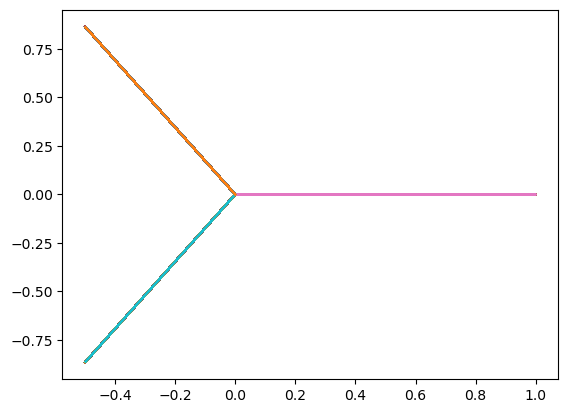

In [9]:

#cursor_pos = nwbfile.processing['behavior'].data_interfaces['Position'].spatial_series['cursor_pos']
go_cue_times = trial_times['go']
window = [0.2, 0.5]  # 200 ms before to 500 ms after go cue

cursor_pos_chunks = get_windowed_pos_chunk(kinematics, timestamps, go_cue_times, window)

for i, chunk in enumerate(cursor_pos_chunks):
    plt.plot(chunk[:,0],chunk[:,1])

In [ ]:
import numpy as np

def get_human_neural_data(nwbfile, times, window):
    """
    Extract neural data from NWB file at specified timestamps with a time window.
    
    This function extracts chunks of neural data from an NWB (Neurodata Without Borders)
    file's ElectricalSeries acquisition data. For each timestamp provided, it extracts
    neural data across all channels within a specified time window around that timestamp.
    
    Parameters
    ----------
    nwbfile : pynwb.NWBFile
        The NWB file object containing the neural data. The neural data should be 
        accessible via nwbfile.acquisition['ElectricalSeries'].
    times : array-like
        Array or list of timestamps (in seconds) at which to extract neural data.
        Each timestamp serves as the center reference point for the extraction window.
    window : list or tuple of length 2
        Time window [start, end] in seconds relative to each timestamp.
        - window[0]: Start of window (typically negative, e.g., -0.1 for 100ms before)
        - window[1]: End of window (typically positive, e.g., 0.1 for 100ms after)
        Must satisfy: window[0] < window[1]
    
    Returns
    -------
    list of numpy.ndarray
        List of 2D arrays, one for each timestamp in `times`. Each array has shape
        (n_samples, n_channels) where:
        - n_samples: Number of samples within the time window
        - n_channels: Number of electrode channels
    
    Raises
    ------
    AssertionError
        If window[0] >= window[1]
    KeyError
        If 'ElectricalSeries' is not found in nwbfile.acquisition
    
    Notes
    -----
    The ElectricalSeries structure contains:
    - starting_time: Initial timestamp (typically 0.0 seconds)
    - rate: Sampling rate in Hz (e.g., 3051.7578125 Hz)
    - data: 2D array of shape (n_timepoints, n_channels) in volts
    - conversion: Scaling factor (e.g., 0.001)
    - unit: Data units (e.g., 'volts')
    
    Examples
    --------
    Extract 200ms windows (±100ms) around three timestamps:
    >>> times = [1.0, 2.5, 5.0]  # seconds
    >>> window = [-0.1, 0.1]  # ±100ms window
    >>> neural_chunks = get_human_neural_data(nwbfile, times, window)
    >>> print(f"Extracted {len(neural_chunks)} chunks")
    >>> print(f"First chunk shape: {neural_chunks[0].shape}")
    
    Extract asymmetric window (50ms before, 150ms after):
    >>> window = [-0.05, 0.15]
    >>> neural_chunks = get_human_neural_data(nwbfile, times, window)
    """
    # Validate window parameter
    assert window[0] < window[1], \
        f"window[0] must be less than window[1], got window={window}"
    
    # Access the ElectricalSeries data
    electrical_series = nwbfile.acquisition['ElectricalSeries']
    
    # Get sampling rate and starting time
    sampling_rate = electrical_series.rate
    starting_time = electrical_series.starting_time
    
    # Access the full neural data (timepoints x channels)
    full_data = electrical_series.data[:]
    
    # Initialize list to store extracted chunks
    neural_data_chunks = []
    
    # Extract data for each timestamp
    for timestamp in times:
        # Calculate absolute time boundaries for this window
        window_start_time = timestamp + window[0]
        window_end_time = timestamp + window[1]
        
        # Convert time boundaries to sample indices
        # Index = (time - starting_time) * sampling_rate
        start_idx = int((window_start_time - starting_time) * sampling_rate)
        end_idx = int((window_end_time - starting_time) * sampling_rate)
        
        # Ensure indices are within valid range
        start_idx = max(0, start_idx)
        end_idx = min(len(full_data), end_idx)
        
        # Extract the data chunk for this time window
        if start_idx < end_idx:
            data_chunk = full_data[start_idx:end_idx, :]
        else:
            # If window is invalid, return empty array with correct channel dimension
            data_chunk = np.array([]).reshape(0, full_data.shape[1])
        
        neural_data_chunks.append(data_chunk)
    
    return neural_data_chunks

f

<HDF5 dataset "data": shape (2009088, 256), type "<f4">

In [ ]:


def get_monkey_neural_data(nwbfile, times, window, bin_size=0.01):
    list_units_spkts = m_nwbfile.units[:]['spike_times']
    spike_data = get_chunk_spikes_binned_windowed(list_units_spkts, times, window, bin_size)
    return spike_data


#h_nwbfile.acquisition['ElectricalSeries'].data[:]
def get_neural_data(nwbfile, times, window, bin_size=0.01):
    """
    """
    if nwbfile.subject.species == 'Macaca mulatta':
        neural_data = get_monkey_neural_data(nwbfile, times, window, bin_size)
        metadata = {
            'species': 'Macaca mulatta',
            'kinematic_type': 'cursor_position'
        }
    elif nwbfile.subject.species == 'Homo sapiens':
        kinematic, timestamps = get_human_neural_data(nwbfile, times, window)
        metadata = {
            'species': 'Homo sapiens',
            'kinematic_type': 'speech_binary'
        }
    else:
        raise ValueError("Missing required field: NWB file does not have monkey or human species")
    
    return neural_data, metadata

neural_data, metadata = get_neural_data(nwbfile, go_cue_times, window)

In [ ]:



print(neural_data[0].shape)
avg_spike_rates = np.mean(neural_data[0],axis=0)
print(avg_spike_rates.shape)


plot_firing_rate_heatmap(avg_spike_rates, time_axis=None, bin_size=None,
                              figsize=(12, 8), cmap='viridis', 
                              vmin=None, vmax=None, title=None)


## Movement Detection

In [ ]:
#nwbfile.processing['behavior'].data_interfaces['Velocity'].time_series

cursor_vel, timestamps, metadata = get_kinematics(m_nwbfile, kin_type="Velocity")


In [ ]:



#cursor_vel = nwbfile.processing['behavior'].['Velocity'].time_series['cursor_vel']

# Usage
movement_times, movement_indices = get_movement_onset_times(
    cursor_vel, 
    timestamps,
    go_cue_times, 
    threshold=5.0,
    window=[-0.1, 1.0]
)

# Filter out trials with no movement detected
valid_trials = ~np.isnan(movement_times)
print(f"Movement detected in {valid_trials.sum()}/{len(go_cue_times)} trials")
print(f"First movement onset at: {movement_times[valid_trials][0]:.3f} seconds")



In [ ]:
window = [0.0, 0.2]
movement_spike_data, metadata = get_neural_data(nwbfile, movement_times[valid_trials], window, bin_size=0.01)

window = [0.2, 0.0]
stationary_spike_data, metadata = get_neural_data(nwbfile, go_cue_times[valid_trials], window, bin_size=0.01)


In [ ]:

data = movement_spike_data[0]
move_category = np.ones(movement_spike_data[0].shape[0], dtype=int)  # All ones for movement


data = np.concatenate([data, stationary_spike_data[0]], axis=0)
move_category = np.concatenate([move_category,
                           np.zeros(stationary_spike_data[0].shape[0], dtype=int)])  # All zeros for stationary


print(move_category.shape)
print(data.shape)



In [ ]:
# Train classifier
lda, results = train_lda_classifier(data, move_category)

# Visualize
plot_lda_results(results)